**Explainable Skin Lesion Classification Framework**

**1. Import Libraries**

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    
#Folders For Save Figures, Tables and Models
os.makedirs("saved_tables_csv", exist_ok=True)
os.makedirs("saved_figures_pdf", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

print("Folders created successfully")

2026-06-07 01:05:56.365906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780794356.599408      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780794356.663535      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780794357.185939      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780794357.185981      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780794357.185984      23 computation_placer.cc:177] computation placer alr

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/kmader
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2
Folders created successfully


**2. Dataset Loading**

In [2]:
DATASET_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = os.path.join(DATASET_PATH, "HAM10000_metadata.csv")

metadata = pd.read_csv(metadata_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", metadata.shape)

display(metadata.head())

Dataset Loaded Successfully
Dataset Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


**3. Data Preprocessing**

In [3]:
lesion_type_dict = {
    'nv': 'Melanocytic Nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}

metadata['lesion_name'] = metadata['dx'].map(lesion_type_dict)

image_paths = {}

for dirname, _, filenames in os.walk(DATASET_PATH):
    for filename in filenames:
        if filename.endswith(".jpg"):
            image_id = filename.split(".")[0]
            image_paths[image_id] = os.path.join(dirname, filename)

metadata['image_path'] = metadata['image_id'].map(image_paths)
metadata = metadata.dropna(subset=['image_path'])

metadata.to_csv("saved_tables_csv/metadata_preprocessed.csv", index=False)

class_distribution = metadata['dx'].value_counts().reset_index()
class_distribution.columns = ['Class', 'Count']
class_distribution.to_csv("saved_tables_csv/class_distribution.csv", index=False)

display(class_distribution)

,Class,Count
0,nv,6705
1,mel,1113
2,bkl,1099
3,bcc,514
4,akiec,327
5,vasc,142
6,df,115


**4. Class Distribution Figure**

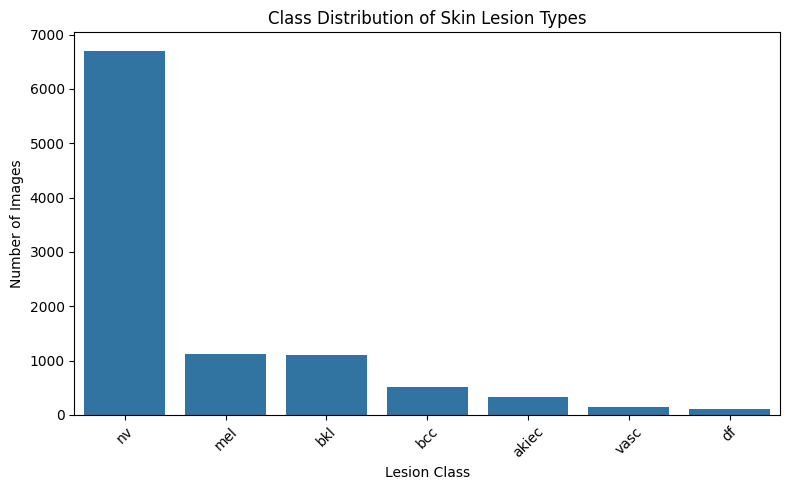

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=metadata, x='dx', order=metadata['dx'].value_counts().index)
plt.title("Class Distribution of Skin Lesion Types")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("saved_figures_pdf/class_distribution.pdf")
plt.show()

**5. Train/Validate/Test Split**

In [5]:
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata['dx'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['dx'],
    random_state=42
)

train_df.to_csv("saved_tables_csv/train_data.csv", index=False)
val_df.to_csv("saved_tables_csv/validation_data.csv", index=False)
test_df.to_csv("saved_tables_csv/test_data.csv", index=False)

split_table = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Images": [len(train_df), len(val_df), len(test_df)]
})

split_table.to_csv("saved_tables_csv/data_split_table.csv", index=False)
display(split_table)


,Dataset,Images
0,Training,7010
1,Validation,1502
2,Testing,1503


**6. Image Resizing, Normalization and Data Augmentation**

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

class_index_table = pd.DataFrame(
    list(train_generator.class_indices.items()),
    columns=["Class", "Index"]
)

class_index_table.to_csv("saved_tables_csv/class_indices.csv", index=False)
display(class_index_table)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


,Class,Index
0,akiec,0
1,bcc,1
2,bkl,2
3,df,3
4,mel,4
5,nv,5
6,vasc,6


**7. Sample Images Figure**

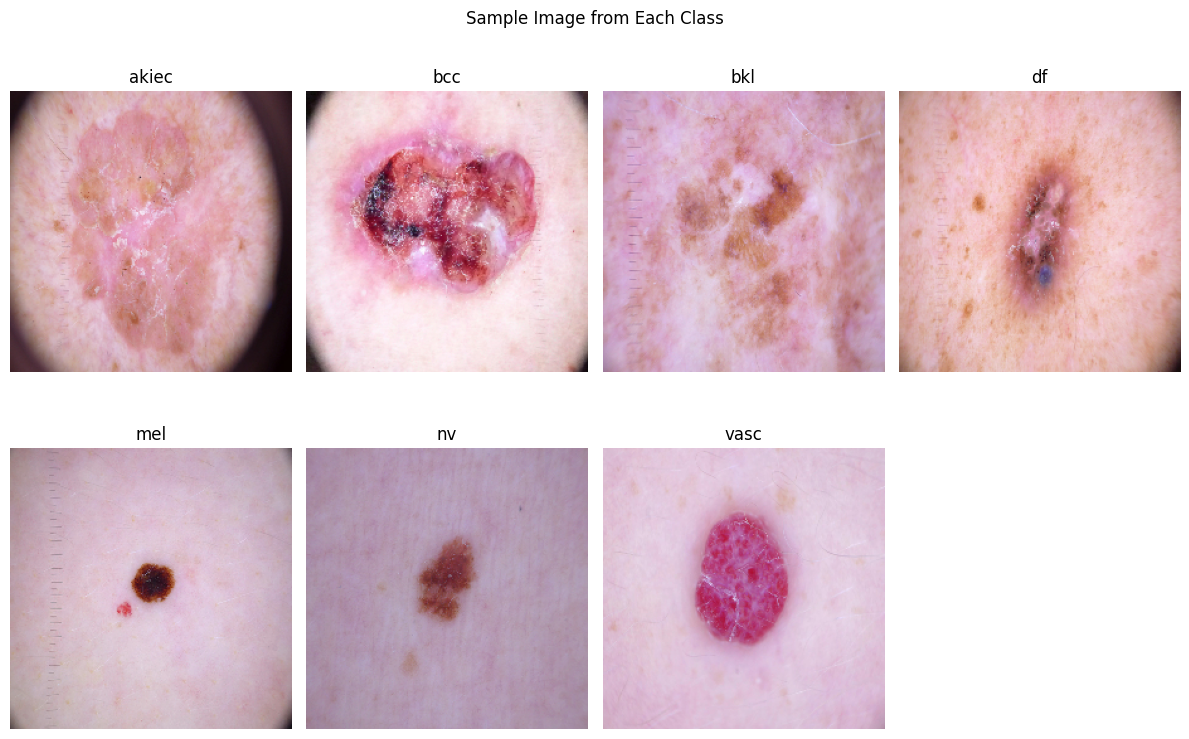

In [7]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(class_names):
    sample_path = metadata[metadata['dx'] == cls].iloc[0]['image_path']
    img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
    
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Image from Each Class")
plt.tight_layout()
plt.savefig("saved_figures_pdf/sample_images_each_class.pdf")
plt.show()

**8. Custom CNN Model Development**

In [8]:
from tensorflow.keras.layers import Input

cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

I0000 00:00:1780794394.280574      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780794394.286657      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**9. CNN Model Training**

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

cnn_history_df = pd.DataFrame(cnn_history.history)
cnn_history_df.to_csv("saved_tables_csv/cnn_training_history.csv", index=False)
display(cnn_history_df)

Epoch 1/10


I0000 00:00:1780794399.972782      72 service.cc:152] XLA service 0x7a9490004600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780794399.972820      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780794399.972824      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780794400.410329      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 01:06:43.027387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:06:43.175492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/220 ━━━━━━━━━━━━━━━━━━━━ 32:03 9s/step - accuracy: 0.0938 - loss: 1.9490

I0000 00:00:1780794406.119979      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


198/220 ━━━━━━━━━━━━━━━━━━━━ 15s 705ms/step - accuracy: 0.6211 - loss: 1.4400

2026-06-07 01:09:05.961157: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:09:06.102899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 184s 800ms/step - accuracy: 0.6593 - loss: 1.1354 - val_accuracy: 0.6691 - val_loss: 0.9542
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 124s 564ms/step - accuracy: 0.6652 - loss: 0.9889 - val_accuracy: 0.6704 - val_loss: 0.9058
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 554ms/step - accuracy: 0.6682 - loss: 0.9449 - val_accuracy: 0.6671 - val_loss: 0.8746
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 553ms/step - accuracy: 0.6718 - loss: 0.9089 - val_accuracy: 0.6758 - val_loss: 0.8840
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 554ms/step - accuracy: 0.6713 - loss: 0.9030 - val_accuracy: 0.6784 - val_loss: 0.8537
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 555ms/step - accuracy: 0.6753 - loss: 0.8816 - val_accuracy: 0.6784 - val_loss: 0.8268
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 556ms/step - accuracy: 0.6796 - loss: 0.8592 - val_accuracy: 0.6864 - val_loss: 0.8415
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 553ms/step - accuracy: 0.6800 - loss: 0.85

,accuracy,loss,val_accuracy,val_loss
0,0.659344,1.135365,0.669108,0.954217
1,0.665193,0.988941,0.670439,0.905791
2,0.668188,0.944888,0.667111,0.874637
3,0.671755,0.908888,0.675766,0.884011
4,0.671327,0.902995,0.678429,0.853682
5,0.675321,0.881640,0.678429,0.826806
6,0.679601,0.859181,0.686418,0.841481
7,0.680029,0.852889,0.690413,0.818015
8,0.682882,0.849749,0.683755,0.844197
9,0.687732,0.820065,0.695739,0.803614


**10. CNN Accuracy and Loss Curves**

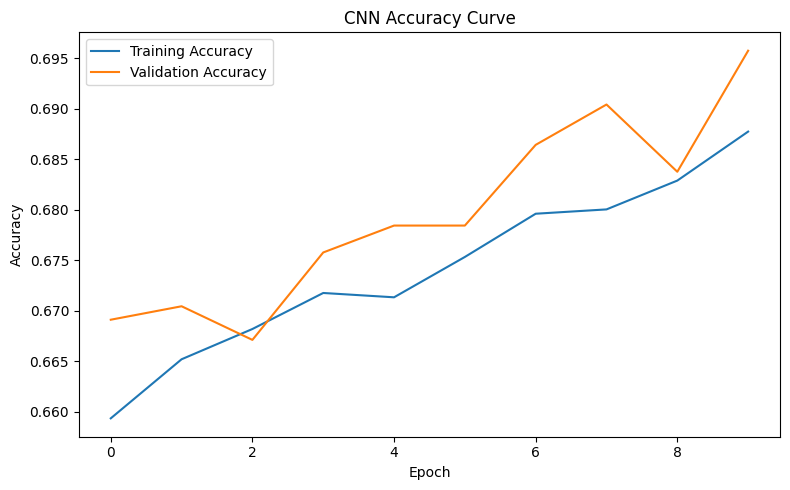

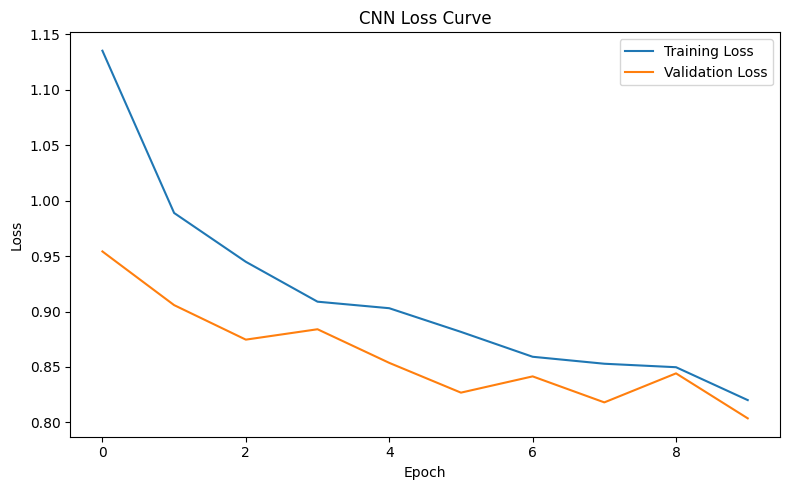

In [10]:
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("saved_figures_pdf/cnn_accuracy_curve.pdf")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("saved_figures_pdf/cnn_loss_curve.pdf")
plt.show()

**11. CNN Model Evaluation**

In [11]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_generator)

cnn_predictions = cnn_model.predict(test_generator)
cnn_pred_classes = np.argmax(cnn_predictions, axis=1)
true_classes = test_generator.classes

cnn_eval_table = pd.DataFrame({
    "Model": ["Custom CNN"],
    "Test Accuracy": [cnn_accuracy],
    "Test Loss": [cnn_loss]
})

cnn_eval_table.to_csv("saved_tables_csv/cnn_evaluation_table.csv", index=False)
display(cnn_eval_table)

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 405ms/step - accuracy: 0.6900 - loss: 0.8063
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step


,Model,Test Accuracy,Test Loss
0,Custom CNN,0.689953,0.806314


**12. CNN Confusion Matrix and Classification Report**

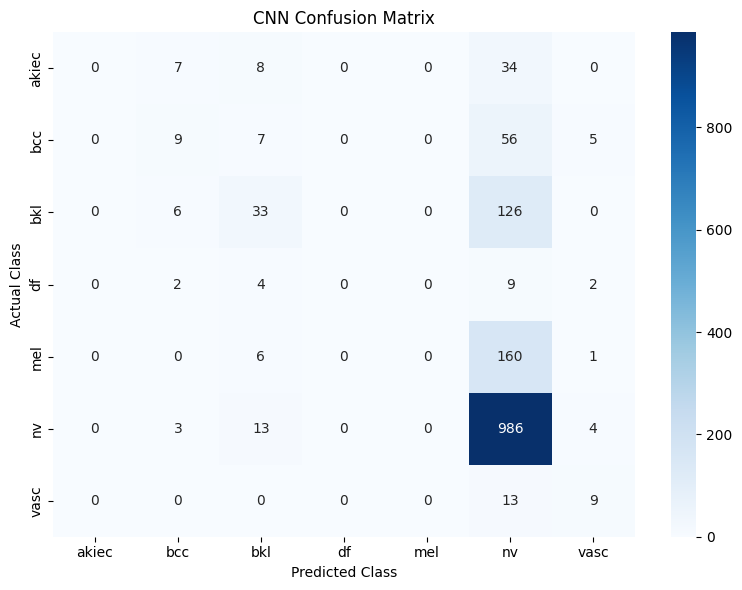

,precision,recall,f1-score,support
akiec,0.000000,0.000000,0.000000,49.000000
bcc,0.333333,0.116883,0.173077,77.000000
bkl,0.464789,0.200000,0.279661,165.000000
df,0.000000,0.000000,0.000000,17.000000
mel,0.000000,0.000000,0.000000,167.000000
nv,0.712428,0.980119,0.825105,1006.000000
vasc,0.428571,0.409091,0.418605,22.000000
accuracy,0.689953,0.689953,0.689953,0.689953
macro avg,0.277017,0.243728,0.242350,1503.000000
weighted avg,0.551223,0.689953,0.597961,1503.000000


In [12]:
cnn_cm = confusion_matrix(true_classes, cnn_pred_classes)

cnn_cm_df = pd.DataFrame(
    cnn_cm,
    index=class_names,
    columns=class_names
)

cnn_cm_df.to_csv("saved_tables_csv/cnn_confusion_matrix.csv")

plt.figure(figsize=(8,6))
sns.heatmap(
    cnn_cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig("saved_figures_pdf/cnn_confusion_matrix.pdf")
plt.show()

cnn_report = classification_report(
    true_classes,
    cnn_pred_classes,
    target_names=class_names,
    output_dict=True
)

cnn_report_df = pd.DataFrame(cnn_report).transpose()
cnn_report_df.to_csv("saved_tables_csv/cnn_classification_report.csv")
display(cnn_report_df)

**13. Transfer Learning Model - MobileNetV2**

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

mobilenet_model = Model(inputs, outputs)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**14. MobileNetV2 Model Training**

In [14]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

mobilenet_history_df = pd.DataFrame(mobilenet_history.history)
mobilenet_history_df.to_csv("saved_tables_csv/mobilenet_training_history.csv", index=False)
display(mobilenet_history_df)

Epoch 1/10


2026-06-07 01:28:52.796127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:28:52.933239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


140/220 ━━━━━━━━━━━━━━━━━━━━ 40s 505ms/step - accuracy: 0.6496 - loss: 1.1258

2026-06-07 01:30:13.817192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:30:13.968106: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:30:14.104266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.6605 - loss: 1.0717

2026-06-07 01:31:18.985677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:31:19.129804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 666ms/step - accuracy: 0.6837 - loss: 0.9474 - val_accuracy: 0.7164 - val_loss: 0.8072
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 552ms/step - accuracy: 0.7127 - loss: 0.8208 - val_accuracy: 0.6951 - val_loss: 0.8119
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 552ms/step - accuracy: 0.7155 - loss: 0.7985 - val_accuracy: 0.7457 - val_loss: 0.7245
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 553ms/step - accuracy: 0.7223 - loss: 0.7774 - val_accuracy: 0.7443 - val_loss: 0.7312
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 549ms/step - accuracy: 0.7268 - loss: 0.7669 - val_accuracy: 0.7430 - val_loss: 0.7246
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 123s 560ms/step - accuracy: 0.7318 - loss: 0.7349 - val_accuracy: 0.7490 - val_loss: 0.7038
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 126s 572ms/step - accuracy: 0.7378 - loss: 0.7207 - val_accuracy: 0.7457 - val_loss: 0.6978
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 126s 571ms/step - accuracy: 0.7354 - loss: 0.73

,accuracy,loss,val_accuracy,val_loss
0,0.683738,0.947406,0.716378,0.807218
1,0.712696,0.820759,0.695073,0.811911
2,0.715549,0.798505,0.745672,0.724475
3,0.722254,0.777394,0.744341,0.731172
4,0.726819,0.766891,0.743009,0.724565
5,0.731812,0.734940,0.749001,0.703818
6,0.737803,0.720710,0.745672,0.697846
7,0.735378,0.730636,0.747004,0.701177
8,0.747076,0.712253,0.749001,0.698673
9,0.745649,0.694952,0.754328,0.700124


**15. MobileNetV2 Accuracy and Loss Curves**

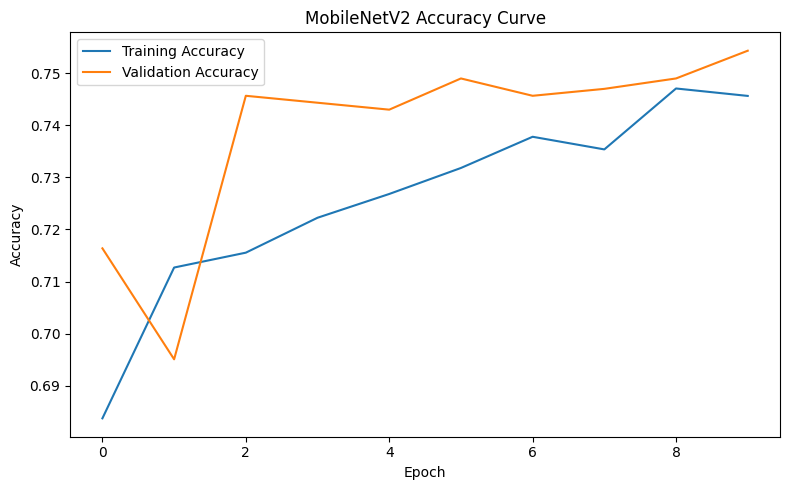

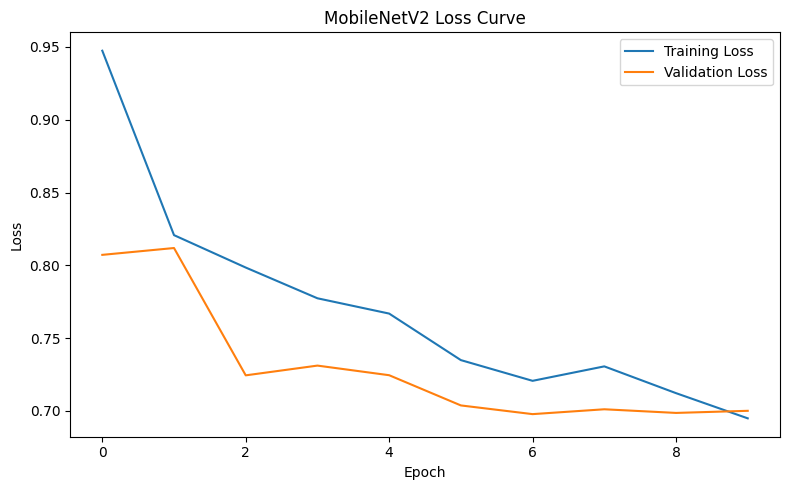

In [15]:
plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("saved_figures_pdf/mobilenet_accuracy_curve.pdf")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("saved_figures_pdf/mobilenet_loss_curve.pdf")
plt.show()

**16. MobileNetV2 Evaluation**

In [16]:
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_generator)

mobilenet_predictions = mobilenet_model.predict(test_generator)
mobilenet_pred_classes = np.argmax(mobilenet_predictions, axis=1)

mobilenet_eval_table = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Test Accuracy": [mobilenet_accuracy],
    "Test Loss": [mobilenet_loss]
})

mobilenet_eval_table.to_csv("saved_tables_csv/mobilenet_evaluation_table.csv", index=False)
display(mobilenet_eval_table)

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7431 - loss: 0.7134

2026-06-07 01:50:14.396587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 01:50:14.533235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.7359 - loss: 0.7518
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 315ms/step


,Model,Test Accuracy,Test Loss
0,MobileNetV2,0.735862,0.751835


**17. MobileNetV2 Confusion Matrix and Classification Report**

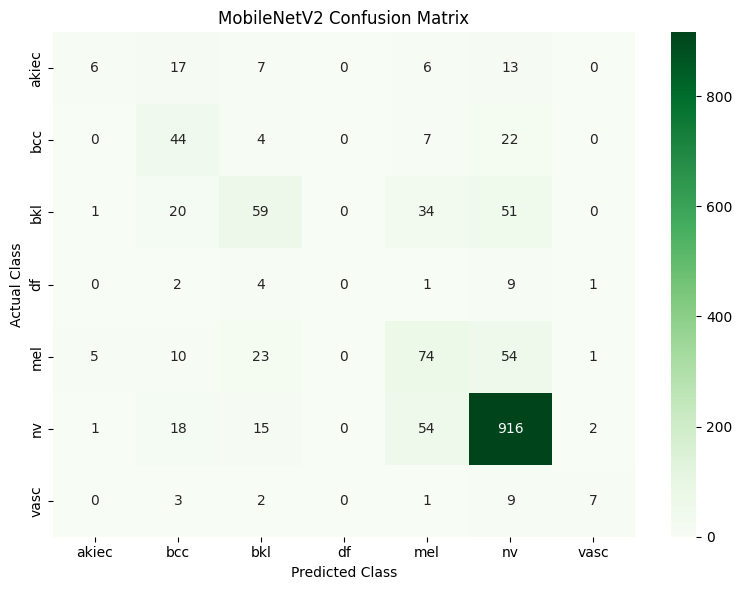

,precision,recall,f1-score,support
akiec,0.461538,0.122449,0.193548,49.000000
bcc,0.385965,0.571429,0.460733,77.000000
bkl,0.517544,0.357576,0.422939,165.000000
df,0.000000,0.000000,0.000000,17.000000
mel,0.418079,0.443114,0.430233,167.000000
nv,0.852886,0.910537,0.880769,1006.000000
vasc,0.636364,0.318182,0.424242,22.000000
accuracy,0.735862,0.735862,0.735862,0.735862
macro avg,0.467482,0.389041,0.401781,1503.000000
weighted avg,0.718265,0.735862,0.719881,1503.000000


In [17]:
mobilenet_cm = confusion_matrix(true_classes, mobilenet_pred_classes)

mobilenet_cm_df = pd.DataFrame(
    mobilenet_cm,
    index=class_names,
    columns=class_names
)

mobilenet_cm_df.to_csv("saved_tables_csv/mobilenet_confusion_matrix.csv")

plt.figure(figsize=(8,6))
sns.heatmap(
    mobilenet_cm_df,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig("saved_figures_pdf/mobilenet_confusion_matrix.pdf")
plt.show()

mobilenet_report = classification_report(
    true_classes,
    mobilenet_pred_classes,
    target_names=class_names,
    output_dict=True
)

mobilenet_report_df = pd.DataFrame(mobilenet_report).transpose()
mobilenet_report_df.to_csv("saved_tables_csv/mobilenet_classification_report.csv")
display(mobilenet_report_df)

**18. Model Comparison Table**

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [cnn_accuracy, mobilenet_accuracy],
    "Test Loss": [cnn_loss, mobilenet_loss],
    "Macro Precision": [
        cnn_report_df.loc["macro avg", "precision"],
        mobilenet_report_df.loc["macro avg", "precision"]
    ],
    "Macro Recall": [
        cnn_report_df.loc["macro avg", "recall"],
        mobilenet_report_df.loc["macro avg", "recall"]
    ],
    "Macro F1-Score": [
        cnn_report_df.loc["macro avg", "f1-score"],
        mobilenet_report_df.loc["macro avg", "f1-score"]
    ]
})

comparison_df.to_csv("saved_tables_csv/model_comparison_table.csv", index=False)
display(comparison_df)

,Model,Test Accuracy,Test Loss,Macro Precision,Macro Recall,Macro F1-Score
0,Custom CNN,0.689953,0.806314,0.277017,0.243728,0.242350
1,MobileNetV2,0.735862,0.751835,0.467482,0.389041,0.401781


**19. Model Comparison Figure**

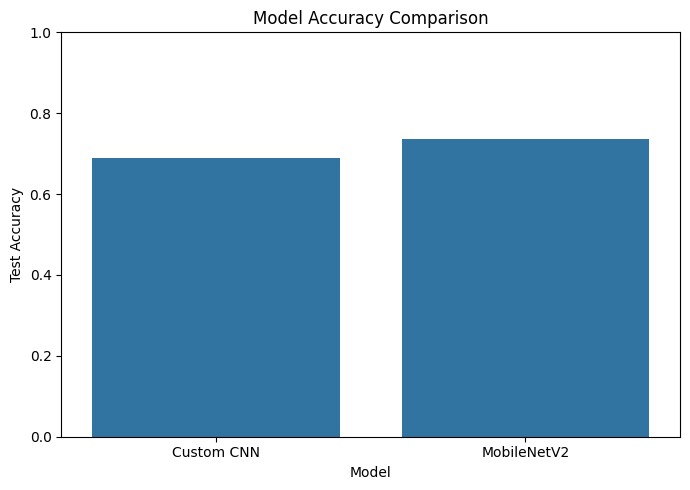

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(data=comparison_df, x="Model", y="Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("saved_figures_pdf/model_accuracy_comparison.pdf")
plt.show()

**20. ROC Curve for MobileNetV2**

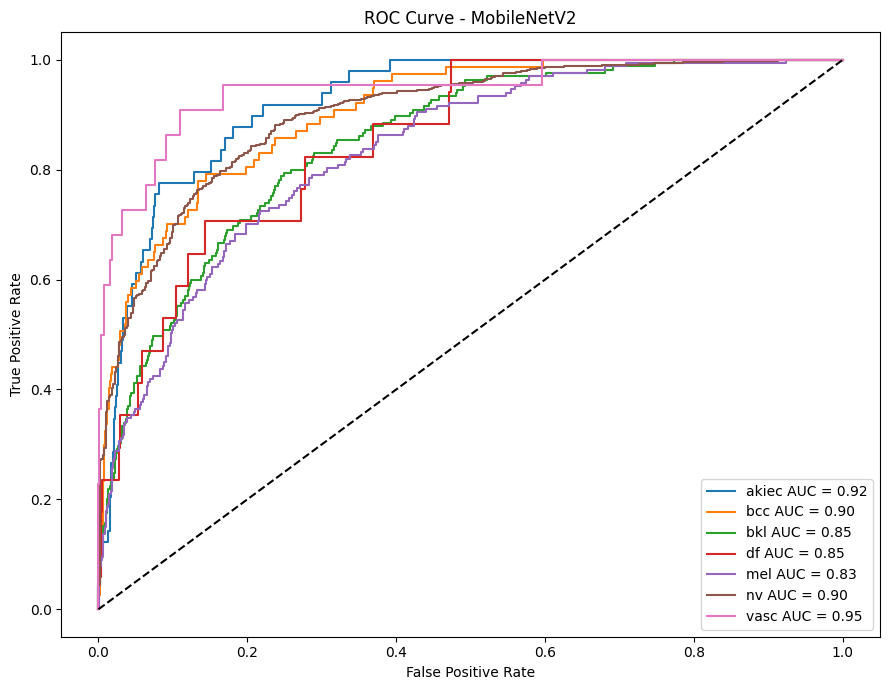

,Class,AUC
0,akiec,0.923350
1,bcc,0.904701
2,bkl,0.850605
3,df,0.853060
4,mel,0.833891
5,nv,0.900306
6,vasc,0.945798


In [20]:
y_true_bin = label_binarize(true_classes, classes=list(range(len(class_names))))

roc_table_list = []

plt.figure(figsize=(9,7))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], mobilenet_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    
    roc_table_list.append({
        "Class": class_names[i],
        "AUC": roc_auc
    })
    
    plt.plot(fpr, tpr, label=f"{class_names[i]} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - MobileNetV2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("saved_figures_pdf/mobilenet_roc_curve.pdf")
plt.show()

roc_auc_table = pd.DataFrame(roc_table_list)
roc_auc_table.to_csv("saved_tables_csv/mobilenet_roc_auc_table.csv", index=False)
display(roc_auc_table)

**21. Error Analysis - Misclassified Images**

,Image Path,True Class,Predicted Class
0,/kaggle/input/datasets/kmader/skin-cancer-mnis...,bkl,bcc
1,/kaggle/input/datasets/kmader/skin-cancer-mnis...,bkl,nv
2,/kaggle/input/datasets/kmader/skin-cancer-mnis...,vasc,nv
3,/kaggle/input/datasets/kmader/skin-cancer-mnis...,bkl,nv
4,/kaggle/input/datasets/kmader/skin-cancer-mnis...,nv,bcc
5,/kaggle/input/datasets/kmader/skin-cancer-mnis...,akiec,bcc
6,/kaggle/input/datasets/kmader/skin-cancer-mnis...,nv,mel
7,/kaggle/input/datasets/kmader/skin-cancer-mnis...,akiec,nv
8,/kaggle/input/datasets/kmader/skin-cancer-mnis...,nv,bkl
9,/kaggle/input/datasets/kmader/skin-cancer-mnis...,nv,mel


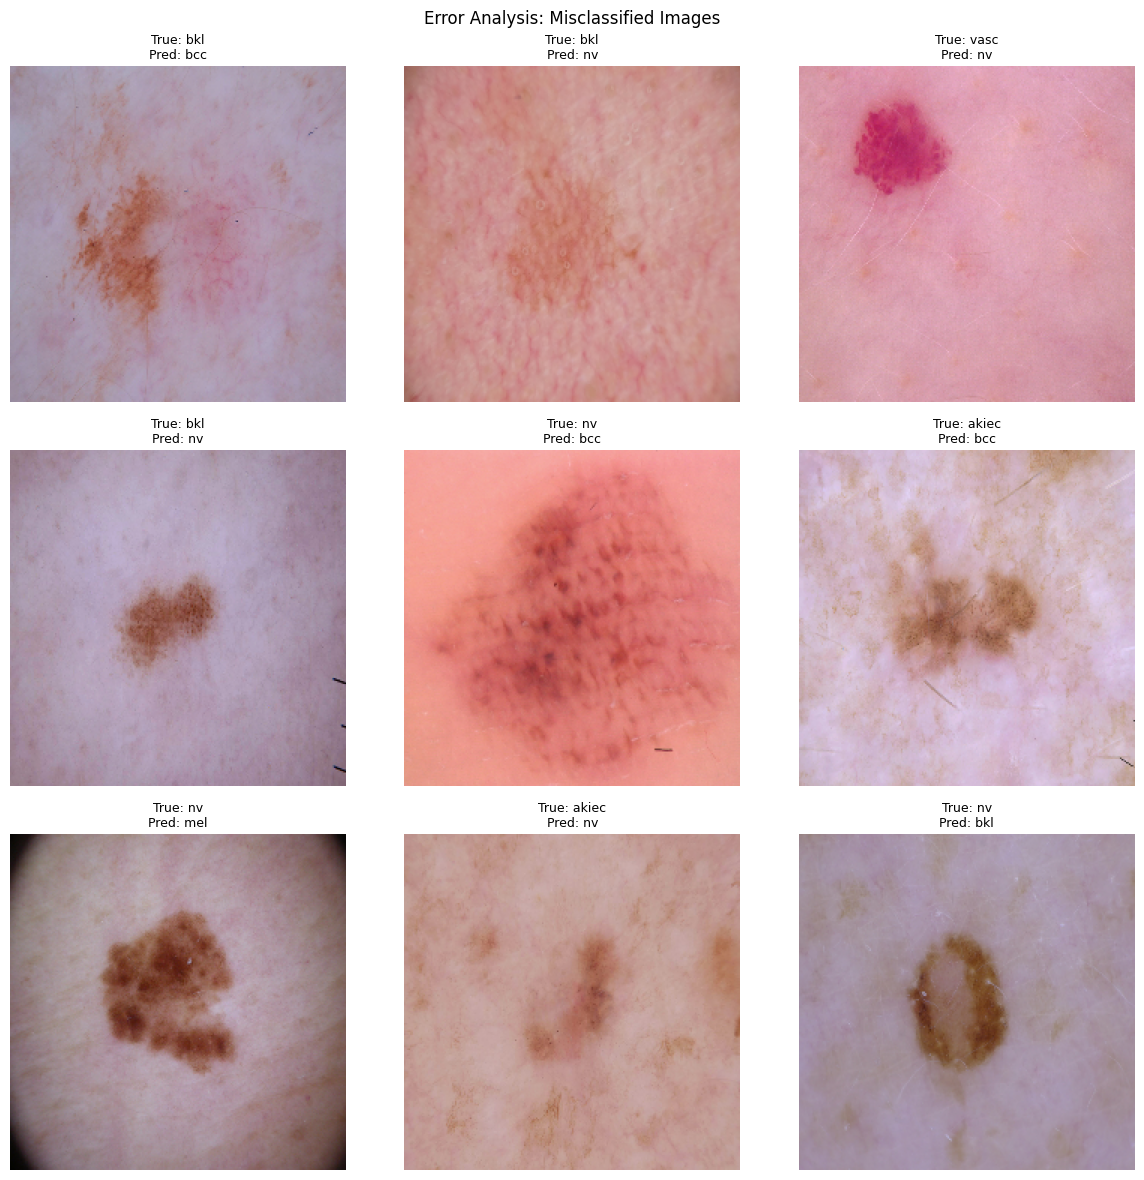

In [21]:
wrong_indices = np.where(true_classes != mobilenet_pred_classes)[0]

error_data = []

for index in wrong_indices:
    error_data.append({
        "Image Path": test_df.iloc[index]['image_path'],
        "True Class": class_names[true_classes[index]],
        "Predicted Class": class_names[mobilenet_pred_classes[index]]
    })

error_analysis_df = pd.DataFrame(error_data)
error_analysis_df.to_csv("saved_tables_csv/error_analysis_wrong_predictions.csv", index=False)
display(error_analysis_df.head(10))

plt.figure(figsize=(12,12))

for i, index in enumerate(wrong_indices[:9]):
    img_path = test_df.iloc[index]['image_path']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0

    plt.subplot(3,3,i+1)
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(
        f"True: {class_names[true_classes[index]]}\nPred: {class_names[mobilenet_pred_classes[index]]}",
        fontsize=9
    )

plt.suptitle("Error Analysis: Misclassified Images")
plt.tight_layout()
plt.savefig("saved_figures_pdf/error_analysis_misclassified_images.pdf")
plt.show()

**22. Grad-CAM Visualization**

,Sample Image,True Class,Predicted Class
0,/kaggle/input/datasets/kmader/skin-cancer-mnis...,bkl,bcc


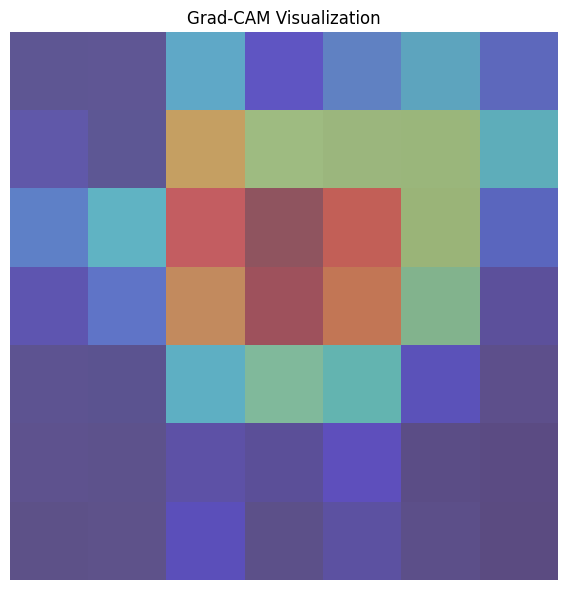

In [22]:
def make_gradcam_heatmap(img_array, base_model, full_model, last_conv_layer_name="Conv_1"):
    
    conv_model = Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    base_model_index = None
    for i, layer in enumerate(full_model.layers):
        if layer.name == base_model.name:
            base_model_index = i
            break

    classifier_layers = full_model.layers[base_model_index + 1:]

    with tf.GradientTape() as tape:
        conv_outputs, x = conv_model(img_array)

        for layer in classifier_layers:
            x = layer(x, training=False)

        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap, predictions


sample_img_path = test_df.iloc[0]['image_path']

img = tf.keras.preprocessing.image.load_img(
    sample_img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array_expanded = np.expand_dims(img_array / 255.0, axis=0)

heatmap, prediction = make_gradcam_heatmap(
    img_array_expanded,
    base_model,
    mobilenet_model,
    last_conv_layer_name="Conv_1"
)

predicted_class = class_names[np.argmax(prediction[0])]
true_class = test_df.iloc[0]['dx']

gradcam_table = pd.DataFrame({
    "Sample Image": [sample_img_path],
    "True Class": [true_class],
    "Predicted Class": [predicted_class]
})

gradcam_table.to_csv("saved_tables_csv/gradcam_sample_prediction.csv", index=False)
display(gradcam_table)

plt.figure(figsize=(6,6))
plt.imshow(img_array.astype("uint8"))
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.tight_layout()
plt.savefig("saved_figures_pdf/gradcam_visualization.pdf")
plt.show()

**23. Save Final Models**

In [23]:
cnn_model.save("saved_models/custom_cnn_skin_lesion_model.keras")
mobilenet_model.save("saved_models/mobilenetv2_skin_lesion_model.keras")